In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BMIState(TypedDict):
    weight_kg: float
    height_m : float
    bmi: float
    category: str

In [3]:
def calc_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi,2)

    return state

In [4]:
def label_bmi(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if(bmi < 18.5):
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal'
    elif 25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'

    return state

In [5]:
wf_graph = StateGraph(BMIState)

wf_graph.add_node("calculate_bmi", calc_bmi)
wf_graph.add_node("labeled_bmi", label_bmi)


wf_graph.add_edge(START, 'calculate_bmi')
wf_graph.add_edge('calculate_bmi', 'labeled_bmi')
wf_graph.add_edge('labeled_bmi', END)

wf_compiled_graph = wf_graph.compile()

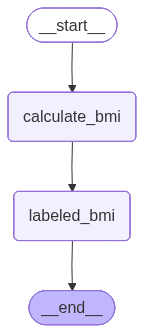

In [6]:
from IPython.display import Image
Image(wf_compiled_graph.get_graph().draw_mermaid_png())

In [7]:
initial_state = {'weight_kg' : 70, 'height_m': 1.77}

final_state = wf_compiled_graph.invoke(initial_state)

print(final_state)

{'weight_kg': 70, 'height_m': 1.77, 'bmi': 22.34, 'category': 'Normal'}
